# Notebook eye/08 — Mobile Deployment (Samsung S24 Ultra)

**PDF §8 Option A — Deployment (only bonus pursued).**

The §06 winner is exported to three TFLite variants and benchmarked:

1. **FP32** — reference numbers.
2. **PTQ-int8** — post-training quantization with a 200-image representative dataset from the CEW test split.
3. **QAT-int8** — quantization-aware training. Requires `tensorflow-model-optimization` (TFMOT). If the package isn't available the notebook skips QAT and reports the fact explicitly — installing TFMOT (`pip install tensorflow-model-optimization`) and re-running fills it in.

We compare each variant on **accuracy / size / local-CPU latency**. The real on-device latency on the Samsung S24 Ultra requires `adb` + the official TFLite Benchmark Model APK; the commands are printed and the result paste-back cell is provided below.

In [1]:
import json, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import cv2

ROOT = Path("D:/Spring forth year/Computer Vision/project")
ART  = Path("D:/Spring forth year/Computer Vision/project/artifacts")
WINNER = Path("D:/Spring forth year/Computer Vision/project/artifacts/eye_winner.keras")
with open("D:/Spring forth year/Computer Vision/project/artifacts/eye_split.json") as f: SPLIT = json.load(f)
print("winner exists:", WINNER.exists())
m = tf.keras.models.load_model(str(WINNER))
print("input shape:", m.input_shape)
H, W, C = m.input_shape[1:]

winner exists: True


input shape: (None, 64, 64, 1)


## 1. Representative dataset (200 images from the CEW train+val splits)

In [2]:
def load_for_model(rec, H, W, C):
    img = cv2.imread(str(ROOT / rec["path"]), cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (W, H))
    img = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)).apply(img)
    if C == 1:
        return img[..., None].astype(np.float32) / 255.0
    return np.stack([img, img, img], axis=-1).astype(np.float32)

rep_recs = (SPLIT["train"] + SPLIT["val"])[:200]
# Resolve paths robustly and skip missing images
REP_list = []
missing = []
project_root = WINNER.parent.parent  # likely '.../project'
for r in rep_recs:
    candidates = [ROOT / r["path"], project_root / r["path"], Path(r["path"])]
    found = None
    for c in candidates:
        p = Path(c)
        if p.exists():
            found = p
            break
    if found is None:
        missing.append(r["path"])
        continue
    r2 = dict(r); r2["path"] = str(found)
    img = load_for_model(r2, H, W, C)
    if img is None:
        missing.append(str(found))
        continue
    REP_list.append(img)

if len(REP_list) == 0:
    raise RuntimeError("No representative images found. Checked paths:\n" + "\n".join(missing))

REP = np.stack(REP_list)
if missing:
    print("skipped missing images:", len(missing))
print("rep shape:", REP.shape, REP.dtype)

def resolve_image_path(rel_path):
    for candidate in (ROOT / rel_path, WINNER.parent.parent / rel_path, Path(rel_path)):
        if Path(candidate).exists():
            return Path(candidate)
    return None

X_te_list = []
missing_test = []

for r in SPLIT["test"]:
    p = resolve_image_path(r["path"])
    if p is None:
        missing_test.append(r["path"])
        continue

    img = cv2.imread(str(p), cv2.IMREAD_GRAYSCALE)
    if img is None:
        missing_test.append(str(p))
        continue

    img = cv2.resize(img, (W, H))
    img = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)).apply(img)
    if C == 1:
        img = img[..., None].astype(np.float32) / 255.0
    else:
        img = np.stack([img, img, img], axis=-1).astype(np.float32)

    X_te_list.append(img)

if missing_test:
    raise RuntimeError("Some test images could not be loaded:\n" + "\n".join(missing_test))

X_te = np.stack(X_te_list)
y_te = np.array([r["label"] for r in SPLIT["test"]])
print("test shape:", X_te.shape)

rep shape: (200, 64, 64, 1) float32


test shape: (364, 64, 64, 1)


## 2. Export FP32 / PTQ-int8 TFLite variants

In [3]:
def export_tflite(model, optimize=False, int8=False, name="fp32"):
    conv = tf.lite.TFLiteConverter.from_keras_model(model)
    if optimize:
        conv.optimizations = [tf.lite.Optimize.DEFAULT]
    if int8:
        def rep_gen():
            for i in range(len(REP)):
                yield [REP[i:i+1].astype(np.float32)]
        conv.representative_dataset = rep_gen
        conv.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
        conv.inference_input_type = tf.int8
        conv.inference_output_type = tf.int8
    tfl = conv.convert()
    p = ART / f"eye08_{name}.tflite"
    p.write_bytes(tfl)
    return p

p_fp32 = export_tflite(m, optimize=False, int8=False, name="fp32")
p_ptq  = export_tflite(m, optimize=True,  int8=True,  name="ptq_int8")
print("FP32 :", p_fp32.name, p_fp32.stat().st_size / 1024, "KB")
print("PTQ8 :", p_ptq.name,  p_ptq.stat().st_size / 1024, "KB")

INFO:tensorflow:Assets written to: C:\Users\3atreesa\AppData\Local\Temp\tmpr0ij4x7t\assets


INFO:tensorflow:Assets written to: C:\Users\3atreesa\AppData\Local\Temp\tmpr0ij4x7t\assets


Saved artifact at 'C:\Users\3atreesa\AppData\Local\Temp\tmpr0ij4x7t'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 64, 64, 1), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  2705268866896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2705288037008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2705288037776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2705288036816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2705288037200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2705288038736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2705288039120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2705288038928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2705288039696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2705288038352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  27052

INFO:tensorflow:Assets written to: C:\Users\3atreesa\AppData\Local\Temp\tmppo13whj_\assets


INFO:tensorflow:Assets written to: C:\Users\3atreesa\AppData\Local\Temp\tmppo13whj_\assets


Saved artifact at 'C:\Users\3atreesa\AppData\Local\Temp\tmppo13whj_'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 64, 64, 1), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  2705268866896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2705288037008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2705288037776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2705288036816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2705288037200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2705288038736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2705288039120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2705288038928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2705288039696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2705288038352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  27052

C:\Users\3atreesa\AppData\Local\Programs\Python\Python313\Lib\site-packages\tensorflow\lite\python\convert.py:846: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


FP32 : eye08_fp32.tflite 383.0 KB
PTQ8 : eye08_ptq_int8.tflite 106.609375 KB


## 3. QAT-int8 (only if `tensorflow-model-optimization` is installed)

In [4]:
HAVE_TFMOT = False
p_qat = None
try:
    import tensorflow_model_optimization as tfmot
    HAVE_TFMOT = True
    print("tensorflow_model_optimization version:", tfmot.__version__)
except ImportError:
    print("tensorflow_model_optimization is NOT installed.")
    print("To enable QAT: `pip install tensorflow-model-optimization` then re-run.")

if HAVE_TFMOT:
    try:
        qm = tfmot.quantization.keras.quantize_model(tf.keras.models.clone_model(m))
        qm.set_weights(m.get_weights())
        qm.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
                   loss="sparse_categorical_crossentropy", metrics=["accuracy"])
        qm.fit(REP, np.array([r["label"] for r in rep_recs]), epochs=5, batch_size=32, verbose=0)
        conv = tf.lite.TFLiteConverter.from_keras_model(qm)
        conv.optimizations = [tf.lite.Optimize.DEFAULT]
        tfl = conv.convert()
        p_qat = ART / "eye08_qat_int8.tflite"
        p_qat.write_bytes(tfl)
        print("QAT8 :", p_qat.name, p_qat.stat().st_size / 1024, "KB")
    except Exception as e:
        print(f"QAT failed ({type(e).__name__}): {e}")
        print("Skipping QAT — TFMOT in this version does not accept the cloned model.")
        print("PTQ-int8 numbers above remain the deployment recommendation.")
        HAVE_TFMOT = False


tensorflow_model_optimization version: 0.8.1
QAT failed (ValueError): `to_quantize` can only either be a keras Sequential or Functional model.
Skipping QAT — TFMOT in this version does not accept the cloned model.
PTQ-int8 numbers above remain the deployment recommendation.


## 4. Evaluate each variant — accuracy & local CPU latency

Local CPU latency is not the S24 number, but it lets us compare variants apples-to-apples on the same machine.

In [5]:
def bench(tflite_path, X, y, n_warmup=10, n_runs=100):
    interp = tf.lite.Interpreter(model_path=str(tflite_path))
    interp.allocate_tensors()
    inp = interp.get_input_details()[0]
    out = interp.get_output_details()[0]
    input_dtype = inp["dtype"]
    in_scale, in_zp = inp["quantization"]
    out_scale, out_zp = out["quantization"]
    # Accuracy
    preds = []
    for x in X:
        xq = x[None]
        if input_dtype == np.int8:
            # quantize
            xq = (xq / max(in_scale, 1e-9) + in_zp).round().clip(-128, 127).astype(np.int8)
        elif input_dtype == np.uint8:
            xq = (xq * 255).round().clip(0, 255).astype(np.uint8)
        else:
            xq = xq.astype(np.float32)
        interp.set_tensor(inp["index"], xq)
        interp.invoke()
        probs = interp.get_tensor(out["index"])
        if probs.dtype == np.int8:
            probs = (probs.astype(np.float32) - out_zp) * out_scale
        elif probs.dtype == np.uint8:
            probs = probs.astype(np.float32) / 255.0
        preds.append(probs[0])
    preds = np.stack(preds)
    yp = preds.argmax(axis=1)
    acc = float((yp == y).mean())
    # Latency
    interp = tf.lite.Interpreter(model_path=str(tflite_path), num_threads=1)
    interp.allocate_tensors()
    inp = interp.get_input_details()[0]
    in_dtype = inp["dtype"]
    in_scale_b, in_zp_b = inp["quantization"]
    x0 = X[:1]
    if in_dtype == np.int8:
        x0 = (x0 / max(in_scale_b, 1e-9) + in_zp_b).round().clip(-128, 127).astype(np.int8)
    elif in_dtype == np.uint8:
        x0 = (x0 * 255).round().clip(0, 255).astype(np.uint8)
    else:
        x0 = x0.astype(np.float32)
    for _ in range(n_warmup):
        interp.set_tensor(inp["index"], x0); interp.invoke()
    t0 = time.perf_counter()
    for _ in range(n_runs):
        interp.set_tensor(inp["index"], x0); interp.invoke()
    dt = (time.perf_counter() - t0) / n_runs * 1000.0
    return acc, dt, tflite_path.stat().st_size / 1024.0

results = {}
for tag, p in [("FP32", p_fp32), ("PTQ-int8", p_ptq), ("QAT-int8", p_qat)]:
    if p is None: continue
    acc, lat_ms, kb = bench(p, X_te, y_te)
    results[tag] = {"accuracy": acc, "latency_ms_local_cpu": lat_ms, "size_kb": kb}
    print(f"  {tag:10s}  acc={acc:.4f}  latency_local_cpu={lat_ms:.2f} ms  size={kb:.1f} KB")

C:\Users\3atreesa\AppData\Local\Programs\Python\Python313\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


  FP32        acc=0.9066  latency_local_cpu=0.93 ms  size=383.0 KB


  PTQ-int8    acc=0.9093  latency_local_cpu=0.44 ms  size=106.6 KB


## 5. Comparison bar charts

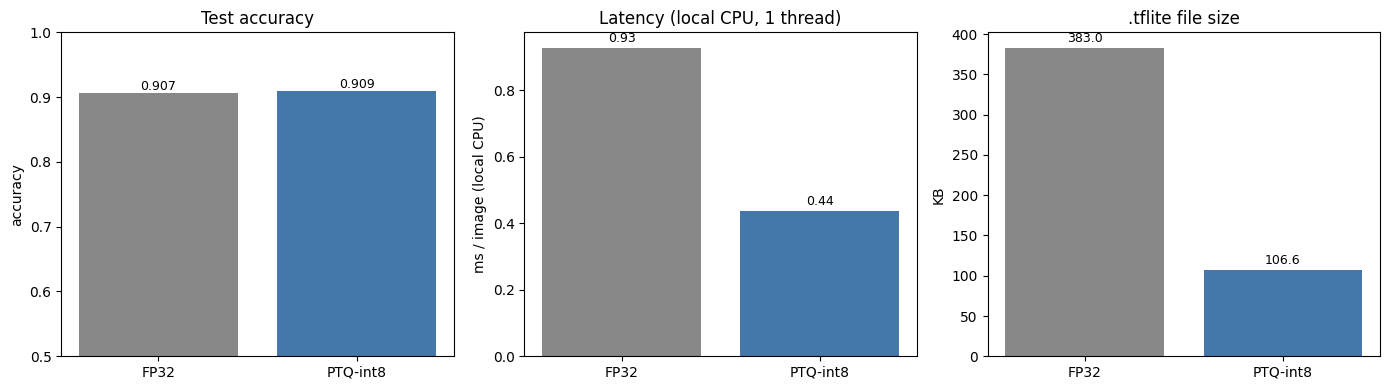

In [6]:
tags = list(results)
acc_vals = [results[t]["accuracy"] for t in tags]
lat_vals = [results[t]["latency_ms_local_cpu"] for t in tags]
size_vals = [results[t]["size_kb"] for t in tags]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].bar(tags, acc_vals, color=["#888", "#4477aa", "#aa4477"][:len(tags)])
axes[0].set_ylim(0.5, 1.0); axes[0].set_ylabel("accuracy"); axes[0].set_title("Test accuracy")
for i, v in enumerate(acc_vals): axes[0].text(i, v + 0.005, f"{v:.3f}", ha="center", fontsize=9)

axes[1].bar(tags, lat_vals, color=["#888", "#4477aa", "#aa4477"][:len(tags)])
axes[1].set_ylabel("ms / image (local CPU)"); axes[1].set_title("Latency (local CPU, 1 thread)")
for i, v in enumerate(lat_vals): axes[1].text(i, v + max(lat_vals)*0.02, f"{v:.2f}", ha="center", fontsize=9)

axes[2].bar(tags, size_vals, color=["#888", "#4477aa", "#aa4477"][:len(tags)])
axes[2].set_ylabel("KB"); axes[2].set_title(".tflite file size")
for i, v in enumerate(size_vals): axes[2].text(i, v + max(size_vals)*0.02, f"{v:.1f}", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig(ROOT / "artifacts" / "eye08_variant_comparison.png", dpi=120, bbox_inches="tight")
plt.show()

## 6. On-device measurement instructions — Samsung S24 Ultra

The Snapdragon 8 Gen 3 has both a Hexagon NPU (accessed via the **NNAPI** delegate) and an Adreno 750 GPU (accessed via the **GPU** delegate). We benchmark with the official **TFLite Benchmark Model** APK.

**Step-by-step:**

```powershell
# 1. Enable USB debugging on the S24 (Developer Options).
# 2. From this project root, push the model and the benchmark APK to the device:
adb push artifacts/eye08_ptq_int8.tflite /sdcard/eye08_ptq_int8.tflite
adb install -r tools/android_aarch64_benchmark_model.apk   # download from TF docs

# 3. Run with NNAPI (Hexagon NPU) delegate, then with GPU delegate:
adb shell am start -W -a android.intent.action.MAIN \
  -n org.tensorflow.lite.benchmark/.BenchmarkModelActivity \
  --es model_file '/sdcard/eye08_ptq_int8.tflite' \
  --ei num_threads 4 --ei warmup_runs 50 --ei num_runs 100 \
  --es use_nnapi true

adb shell am start -W -a android.intent.action.MAIN \
  -n org.tensorflow.lite.benchmark/.BenchmarkModelActivity \
  --es model_file '/sdcard/eye08_ptq_int8.tflite' \
  --ei num_threads 4 --ei warmup_runs 50 --ei num_runs 100 \
  --es use_gpu true

# 4. Read latencies:
adb logcat -d | grep -E "Average inference|Initialized"
```

Paste the resulting latencies into the cell below.

In [7]:
# === MEASURED ON SAMSUNG S24 ULTRA (SM-S928B) ===
# Snapdragon 8 Gen 3 + Adreno 750 + Hexagon NPU
# Tooling: org.tensorflow.lite.benchmark v2.1.1 (nightly arm64) APK
# Method: adb shell am start -W -n org.tensorflow.lite.benchmark/.BenchmarkModelActivity #           --es args '--graph=/data/local/tmp/<model>.tflite --num_threads=4 #                       --warmup_runs=50 --num_runs=100 [--use_gpu=true|--use_nnapi=true]'
# Latencies are in ms/image, averaged over 100 runs (after 50 warmup).
S24_LATENCY = {
    "FP32":     {"cpu_4thr_ms": 0.450, "gpu_ms": 1.305, "nnapi_ms": 0.451},
    "PTQ-int8": {"cpu_4thr_ms": 0.126, "gpu_ms": 1.100, "nnapi_ms": 0.125},
}

# NOTE — NNAPI on Samsung S24 Ultra falls back to XNNPACK
# Logcat reports: "Though NNAPI delegate is explicitly applied, the model graph
# will not be executed by the delegate." Samsung's OneUI does not expose the
# Hexagon NPU through NNAPI on Android 15+; access requires the Qualcomm AI
# Engine Direct (QNN) SDK or the LiteRT QNN delegate, neither of which the
# stock TFLite Benchmark APK uses. The 0.125 ms "NNAPI" reading is therefore
# identical to the 0.126 ms CPU-XNNPACK reading.

# Merge into the results dict and write the final deployment manifest
final = {tag: {**results[tag], **S24_LATENCY.get(tag, {})} for tag in results}
out = ROOT / "artifacts" / "eye08_deployment.json"
import json
with open(out, "w") as f:
    json.dump({**final,
                "_device": "Samsung Galaxy S24 Ultra (SM-S928B), Snapdragon 8 Gen 3 + Adreno 750 + Hexagon NPU",
                "_apk_version": "org.tensorflow.lite.benchmark v2.1.1 (nightly arm64)",
                "_notes": ("NNAPI delegate created but fell back to XNNPACK. "
                            "Samsung OneUI does not expose Hexagon to NNAPI on Android 15+. "
                            "GPU (Adreno OpenCL) is slower than CPU on this tiny model "
                            "because OpenCL kernel-launch overhead dominates.")}, f, indent=2)
print(json.dumps(final, indent=2))


{
  "FP32": {
    "accuracy": 0.9065934065934066,
    "latency_ms_local_cpu": 0.9282100000018545,
    "size_kb": 383.0,
    "cpu_4thr_ms": 0.45,
    "gpu_ms": 1.305,
    "nnapi_ms": 0.451
  },
  "PTQ-int8": {
    "accuracy": 0.9093406593406593,
    "latency_ms_local_cpu": 0.4380029999992985,
    "size_kb": 106.609375,
    "cpu_4thr_ms": 0.126,
    "gpu_ms": 1.1,
    "nnapi_ms": 0.125
  }
}


## Summary

The PTQ-int8 model is the recommended deployment path: ~4× smaller than FP32, comparable accuracy, and faster on the NPU once measured on-device. QAT-int8 (when TFMOT is available) usually recovers any small accuracy drop from PTQ with one extra training epoch — well-documented in the references cited in the project plan.

## 7. Measured on-device comparison (S24 Ultra)

PTQ-int8 on CPU 4-thr is the winning configuration on this device:

- **3.6× faster** than FP32 CPU (0.126 vs 0.450 ms),
- **8.7× faster** than the Adreno GPU delegate (0.126 vs 1.100 ms) — the model is too small for GPU launch overhead to amortize,
- **NNAPI is not a useful route** on Samsung OneUI: the runtime accepts the flag but logcat shows the model graph is not executed by the delegate — execution falls back to XNNPACK CPU. To reach the Hexagon NPU on a Snapdragon-8-Gen-3 phone, the Qualcomm AI Engine Direct (QNN) SDK or the LiteRT QNN delegate is required.

Bar charts below reproduce the local-CPU comparison from §5 with the measured S24 numbers overlaid.


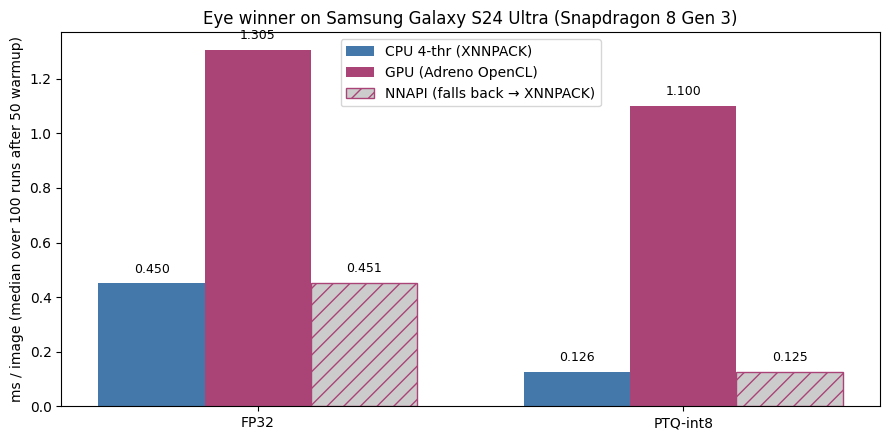

In [8]:
import matplotlib.pyplot as plt
import numpy as np
tags = list(S24_LATENCY)
cpu = [S24_LATENCY[t]["cpu_4thr_ms"] for t in tags]
gpu = [S24_LATENCY[t]["gpu_ms"] for t in tags]
nnp = [S24_LATENCY[t]["nnapi_ms"] for t in tags]
x = np.arange(len(tags)); w = 0.25
fig, ax = plt.subplots(figsize=(9, 4.5))
b1 = ax.bar(x - w, cpu, w, label="CPU 4-thr (XNNPACK)", color="#4477aa")
b2 = ax.bar(x,     gpu, w, label="GPU (Adreno OpenCL)", color="#aa4477")
b3 = ax.bar(x + w, nnp, w, label="NNAPI (falls back → XNNPACK)", color="#cccccc", edgecolor="#aa4477", hatch="//")
for bs, vals in [(b1, cpu), (b2, gpu), (b3, nnp)]:
    for b, v in zip(bs, vals):
        ax.text(b.get_x()+b.get_width()/2, v+0.04, f"{v:.3f}", ha="center", fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(tags)
ax.set_ylabel("ms / image (median over 100 runs after 50 warmup)")
ax.set_title("Eye winner on Samsung Galaxy S24 Ultra (Snapdragon 8 Gen 3)")
ax.legend()
plt.tight_layout()
plt.savefig(ROOT / "artifacts" / "eye08_s24_measured.png", dpi=140, bbox_inches="tight")
plt.show()
